# Modelling total shots a team takes

## Modelling a probability distribution

To model the total number of shots taken, we can separately model expected home shots vs expected away shots.

We can start off by using a linear regression just to understand basic relationships, actually use Poisson/Neg Bin to model the shots, Try using tree based model to see how much we are leaving out.

### Shots can be dependant on
- odds of the team winning/drawing/losing (Probably cannot add all three due to collinearity, but can add any two)
- An adjusted indicator matric of the rolling average of the number of shots the team took based on if they were home or away and how strong their opponents were
- League (might include it, but not sure for now)

### Different questions to test out in modelling

- How does the model do with a linear regression/poisson distribution/tree model
- If we need a league/season/both terms or not
- See which two odds I should add
- Potentially work with different types of adjusted rolling shots
- See if past variance in shots can influence our model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Data

We can start off with a dataset of all matches: Can add Premier League, Serie A, Bundesliga, La Liga past 5 seasons each.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

data   = pd.read_csv('/content/drive/MyDrive/shots_odds/Model_2/football_data.csv')
data_2 = pd.read_csv('/content/drive/MyDrive/shots_odds/Model_2/football_data_adjcols.csv')

Mounted at /content/drive


In [3]:
data

,Unnamed: 0,date,home_team,away_team,home_shots,away_shots,odds_h,odds_d,odds_a,league,season,prob_h,prob_d,prob_a
0,0,2019-08-09,Liverpool,Norwich,15.0,12.0,1.16,10.00,23.00,premier_league,1920,0.857313,0.099448,0.043238
1,1,2019-08-10,West Ham,Man City,5.0,14.0,13.00,6.75,1.29,premier_league,1920,0.076903,0.148109,0.774988
2,2,2019-08-10,Bournemouth,Sheffield United,13.0,8.0,2.06,3.65,4.00,premier_league,1920,0.480912,0.271419,0.247670
3,3,2019-08-10,Burnley,Southampton,10.0,11.0,2.80,3.33,2.85,premier_league,1920,0.354196,0.297822,0.347982
4,4,2019-08-10,Crystal Palace,Everton,6.0,10.0,3.21,3.40,2.52,premier_league,1920,0.310759,0.293393,0.395848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8670,8671,2025-05-25,Empoli,Verona,14.0,5.0,2.04,3.40,4.35,serie_a,2425,0.483333,0.290000,0.226667
8671,8672,2025-05-25,Lazio,Lecce,26.0,9.0,1.64,3.86,8.00,serie_a,2425,0.613546,0.260677,0.125777
8672,8673,2025-05-25,Torino,Roma,11.0,15.0,6.33,4.33,1.60,serie_a,2425,0.155808,0.227775,0.616417
8673,8674,2025-05-25,Udinese,Fiorentina,12.0,25.0,3.81,3.75,2.06,serie_a,2425,0.258698,0.262837,0.478465


### Create columns for Adjusted shots

- Adjusted shots H/A
- Adjusted shots conceded H/A

I am working on the adjusted shots, for which I will need to figure out how to adjust for H/A and strength of opponent.

# Adjusted Shots Feature Engineering

#### Step 1 — Venue Neutralisation
For each game in a team's rolling window, we adjust the raw shot count to a neutral baseline using the league-season expanding average:

- If the team was **at home**: subtract the home premium
- If the team was **away**: add the away discount

$$\text{NeutralShots} = \text{RawShots} - (\text{ExpandingAvgHomeShots} - \text{ExpandingNeutral}) \quad \text{if home}$$
$$\text{NeutralShots} = \text{RawShots} + (\text{ExpandingNeutral} - \text{ExpandingAvgAwayShots}) \quad \text{if away}$$

The neutral baseline is computed as an **expanding average within the current season only**, using only games played prior to the current match to avoid lookahead bias.

#### Step 2 — Opponent Strength Adjustment
We then scale the neutral shots by how difficult the opponent was to generate shots against:

$$\text{AdjShots} = \text{NeutralShots} \times \frac{\text{LeagueSeasonExpandingAvgShotsConc}}{\text{OpponentRollingAvgShotsConc}}$$

- A strong defensive opponent (low shots conceded) scales the value **up**
- A weak defensive opponent (high shots conceded) scales the value **down**

The opponent's defensive strength is their rolling average shots conceded over their last 5 games in the current season.

#### Step 3 — Rolling Average
Finally, we take the **rolling mean of the last 5 adjusted shots values** within the current season:

$$\text{RollingAdjShots} = \frac{1}{N}\sum_{i=1}^{N} \text{AdjShots}_i \quad N \in [3, 5]$$

#### Rules
- **Same season only** — rolling window never crosses a season boundary
- **Minimum 3 games** — fewer than 3 prior games in the season returns NaN
- **No lookahead** — all averages use only information available before the match
- **Computed separately** for shots scored and shots conceded, for both home and away teams, yielding 4 features per match:
  - `home_adj_shots` — home team's adjusted attacking output
  - `home_adj_shots_conc` — home team's adjusted defensive softness
  - `away_adj_shots` — away team's adjusted attacking output
  - `away_adj_shots_conc` — away team's adjusted defensive softness

#### Check for shots throughout the seasons

I want to see how total average shots per match, home shots per match and away shots per match differ across seasons and leagues

In [4]:
data['total_shots'] = data['home_shots'] + data['away_shots']

league_season_avg = (data.groupby(['league', 'season'])['total_shots']
                     .mean()
                     .reset_index()
                     .rename(columns={'total_shots': 'avg_total_shots'}))

print(league_season_avg)

            league  season  avg_total_shots
0       bundesliga    1920        26.529412
1       bundesliga    2021        24.650327
2       bundesliga    2122        25.718954
3       bundesliga    2223        25.287582
4       bundesliga    2324        27.179739
5       bundesliga    2425        25.796721
6          la_liga    1920        22.600000
7          la_liga    2021        21.347368
8          la_liga    2122        23.550000
9          la_liga    2223        24.623684
10         la_liga    2324        24.463158
11         la_liga    2425        23.692105
12  premier_league    1920        24.723684
13  premier_league    2021        24.178947
14  premier_league    2122        25.584211
15  premier_league    2223        25.263158
16  premier_league    2324        27.584211
17  premier_league    2425        25.918421
18         serie_a    1920        21.147368
19         serie_a    2021        21.902632
20         serie_a    2122        25.881579
21         serie_a    2223      

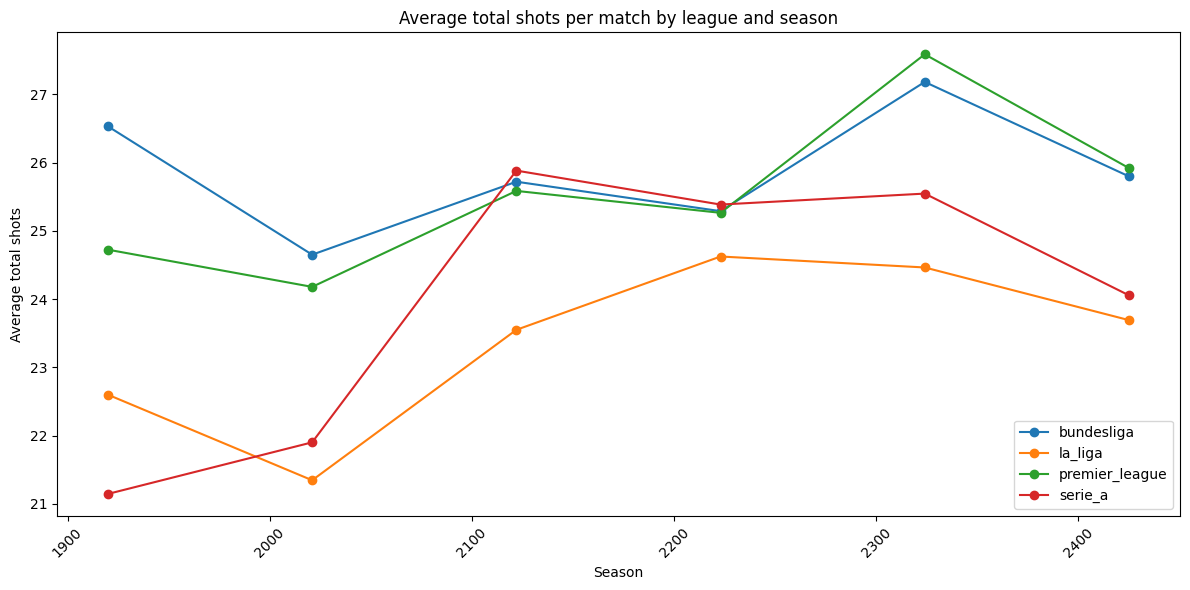

In [5]:
leagues = league_season_avg['league'].unique()

plt.figure(figsize=(12, 6))
for league in leagues:
    subset = league_season_avg[league_season_avg['league'] == league]
    plt.plot(subset['season'], subset['avg_total_shots'], marker='o', label=league)

plt.title('Average total shots per match by league and season')
plt.xlabel('Season')
plt.ylabel('Average total shots')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

What this graph shows us is we have to take into account both season and league, so we prepared the data on this basis

## Linear Regression

In [6]:
# ── Hyperparameters ─────────────────────────────────────────
RETRAIN_EVERY  = 100   # retrain every N rows
MIN_TRAIN_SIZE = 2000  # minimum rows before first prediction
# ────────────────────────────────────────────────────────────

# Sort by date to ensure temporal order — must happen before feature slicing
data_2 = data_2.sort_values('date').reset_index(drop=True)

Y_home = data_2['home_shots']
Y_away = data_2['away_shots']

X_home = data_2[['league', 'prob_h', 'prob_d', 'home_adj_shots', 'away_adj_shots_conc']]
X_away = data_2[['league', 'prob_d', 'prob_a', 'away_adj_shots', 'home_adj_shots_conc']]

X_home = pd.get_dummies(X_home, columns=['league'], drop_first=True).astype(float)
X_away = pd.get_dummies(X_away, columns=['league'], drop_first=True).astype(float)

print("Home features:", X_home.columns.tolist())
print("Away features:", X_away.columns.tolist())

Home features: ['prob_h', 'prob_d', 'home_adj_shots', 'away_adj_shots_conc', 'league_la_liga', 'league_premier_league', 'league_serie_a']
Away features: ['prob_d', 'prob_a', 'away_adj_shots', 'home_adj_shots_conc', 'league_la_liga', 'league_premier_league', 'league_serie_a']


In [7]:
home_model = LinearRegression()
away_model = LinearRegression()
results = []

for i in range(MIN_TRAIN_SIZE, len(data_2)):

    if (i - MIN_TRAIN_SIZE) % RETRAIN_EVERY == 0:
        home_model.fit(X_home.iloc[:i], Y_home.iloc[:i])
        away_model.fit(X_away.iloc[:i], Y_away.iloc[:i])

    pred_home  = home_model.predict(X_home.iloc[[i]])[0]
    pred_away  = away_model.predict(X_away.iloc[[i]])[0]

    results.append({
        'date':         data_2['date'].iloc[i],
        'home_team':    data_2['home_team'].iloc[i],
        'away_team':    data_2['away_team'].iloc[i],
        'pred_home':    pred_home,
        'pred_away':    pred_away,
        'pred_total':   pred_home + pred_away,
        'actual_home':  Y_home.iloc[i],
        'actual_away':  Y_away.iloc[i],
        'actual_total': Y_home.iloc[i] + Y_away.iloc[i],
    })

results_df = pd.DataFrame(results)
print(f"Total predictions: {len(results_df)}")
print(results_df.head())

Total predictions: 5258
         date home_team   away_team  pred_home  pred_away  pred_total  \
0  2021-03-14    Torino       Inter   9.005912  14.055047   23.060959   
1  2021-03-14   Arsenal   Tottenham  11.486311  11.352566   22.838877   
2  2021-03-14     Celta  Ath Bilbao  10.067086   9.739093   19.806179   
3  2021-03-14   Granada    Sociedad   8.549412  12.617791   21.167203   
4  2021-03-14     Eibar  Villarreal  12.157721   9.106180   21.263901   

   actual_home  actual_away  actual_total  
0          6.0         13.0          19.0  
1         13.0          6.0          19.0  
2         13.0          6.0          19.0  
3          7.0          7.0          14.0  
4         16.0         13.0          29.0  


In [8]:
def print_metrics(results_df):
    """Print RMSE, MAE and R² for home, away and total shots."""
    for label, pred_col, actual_col in [
        ('HOME SHOTS',  'pred_home',  'actual_home'),
        ('AWAY SHOTS',  'pred_away',  'actual_away'),
        ('TOTAL SHOTS', 'pred_total', 'actual_total'),
    ]:
        y_true = results_df[actual_col]
        y_pred = results_df[pred_col]
        print(f"\n{label}")
        print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.3f}")
        print(f"MAE:  {mean_absolute_error(y_true, y_pred):.3f}")
        print(f"R²:   {r2_score(y_true, y_pred):.3f}")

print_metrics(results_df)


HOME SHOTS
RMSE: 4.708
MAE:  3.670
R²:   0.247

AWAY SHOTS
RMSE: 4.237
MAE:  3.319
R²:   0.228

TOTAL SHOTS
RMSE: 5.684
MAE:  4.484
R²:   0.074


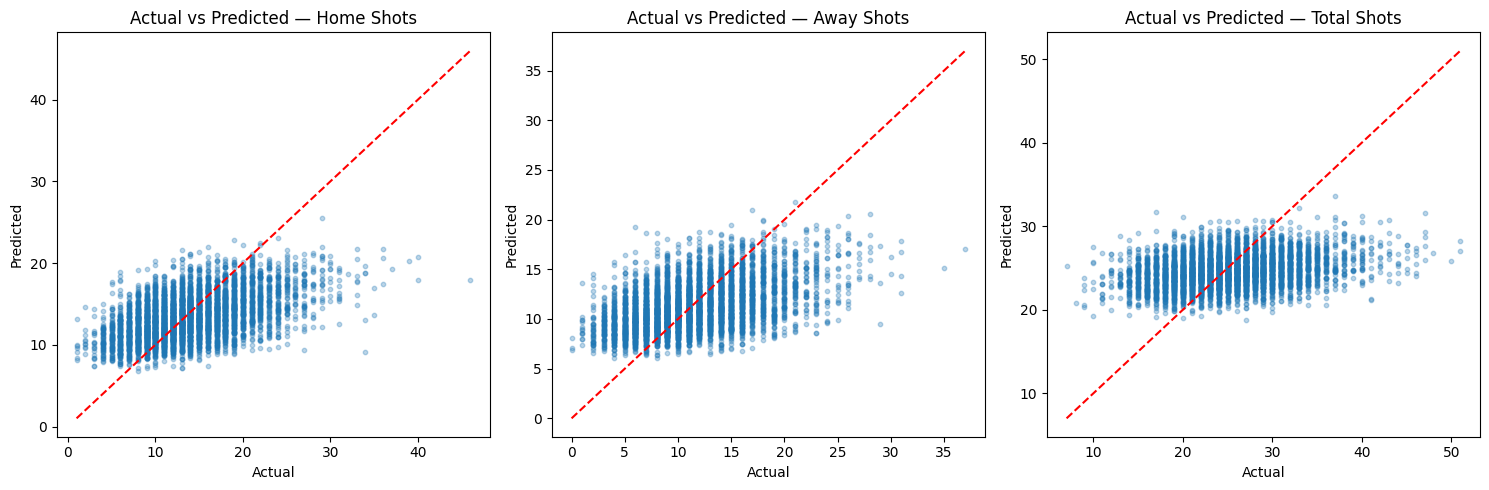

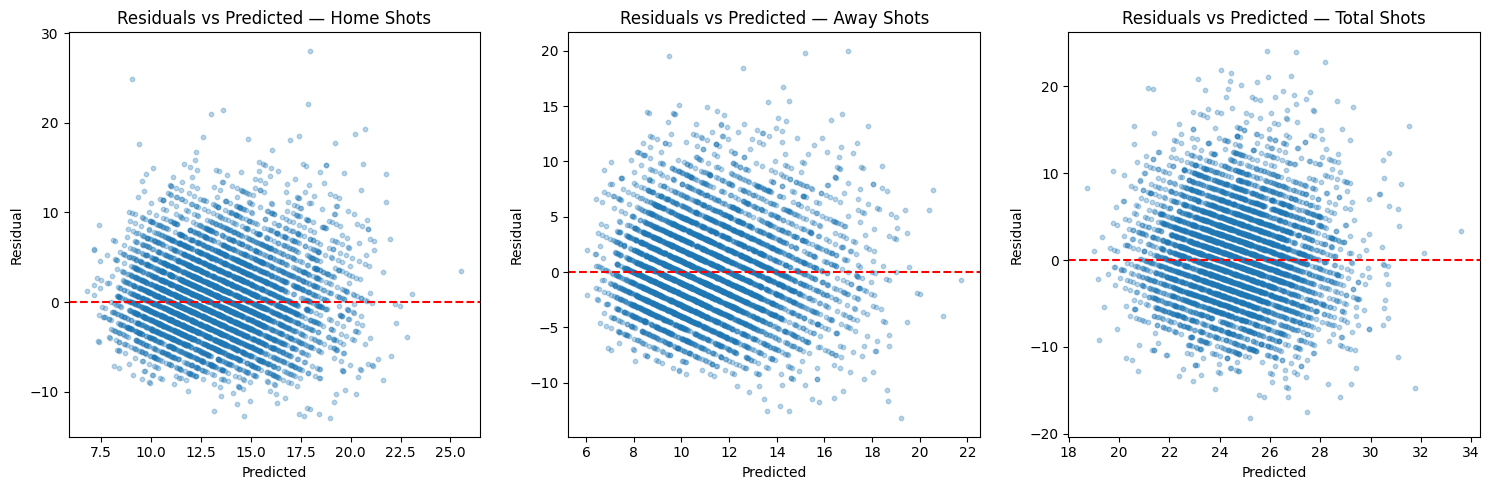

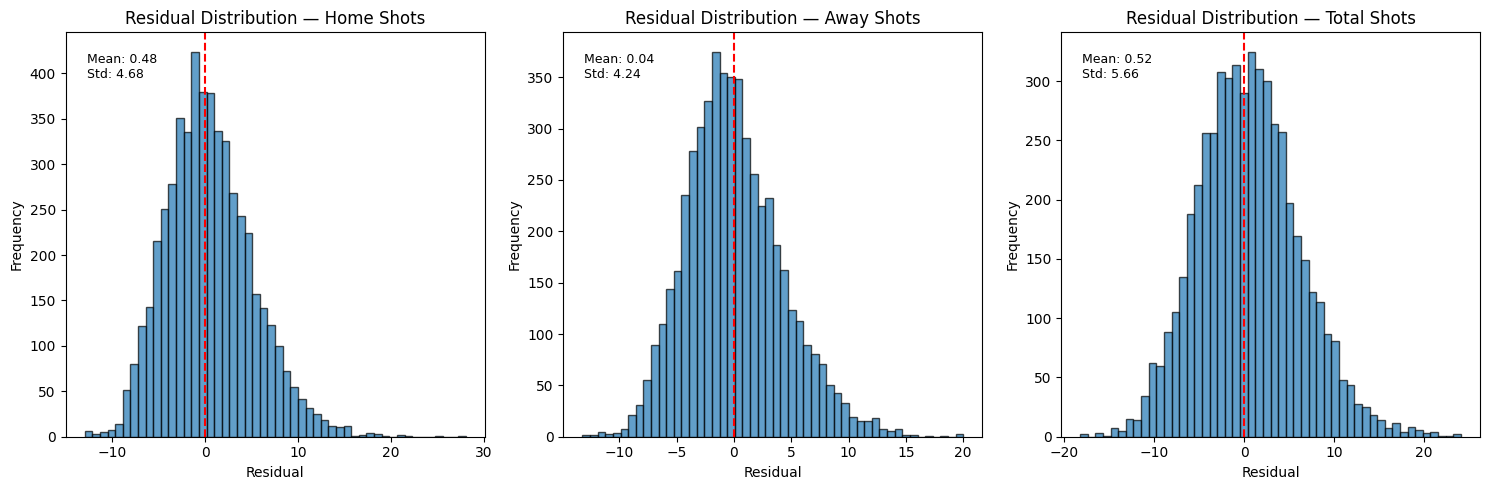

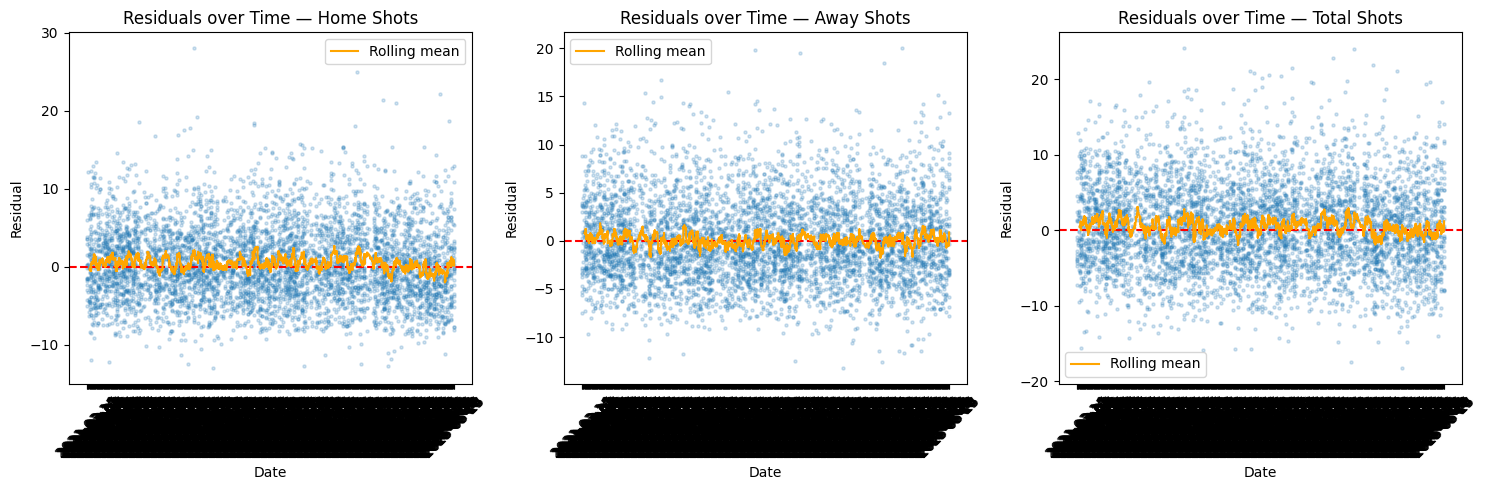

/tmp/ipykernel_8593/3881504779.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([plot_df[plot_df['league'] == l]['residual'] for l in leagues],
/tmp/ipykernel_8593/3881504779.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([plot_df[plot_df['league'] == l]['residual'] for l in leagues],
/tmp/ipykernel_8593/3881504779.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([plot_df[plot_df['league'] == l]['residual'] for l in leagues],


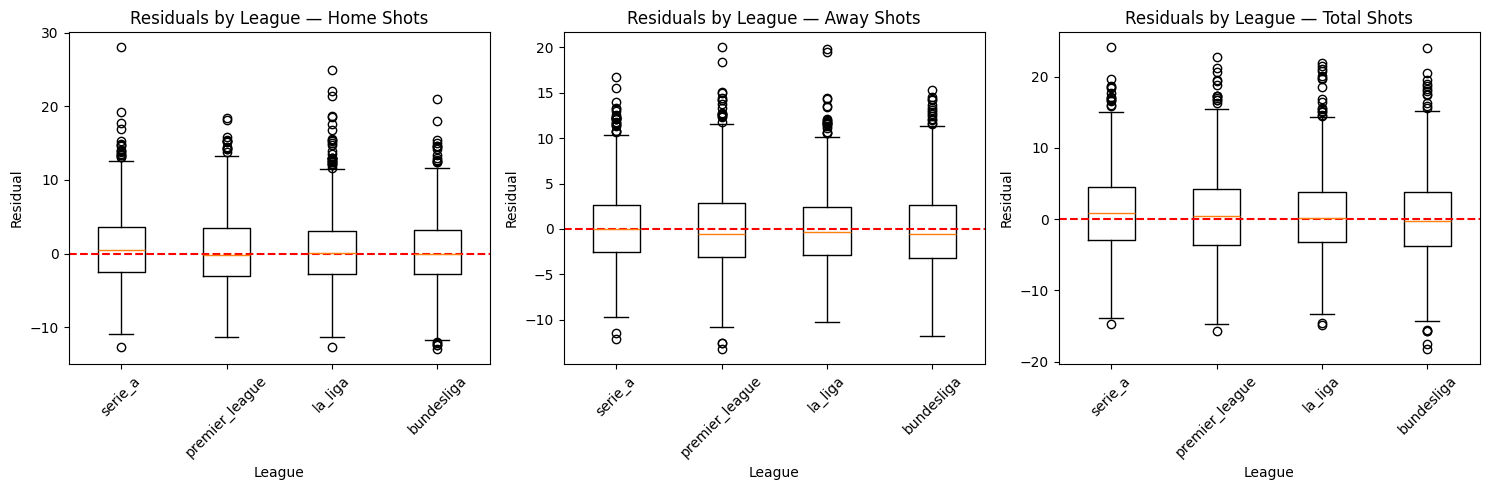

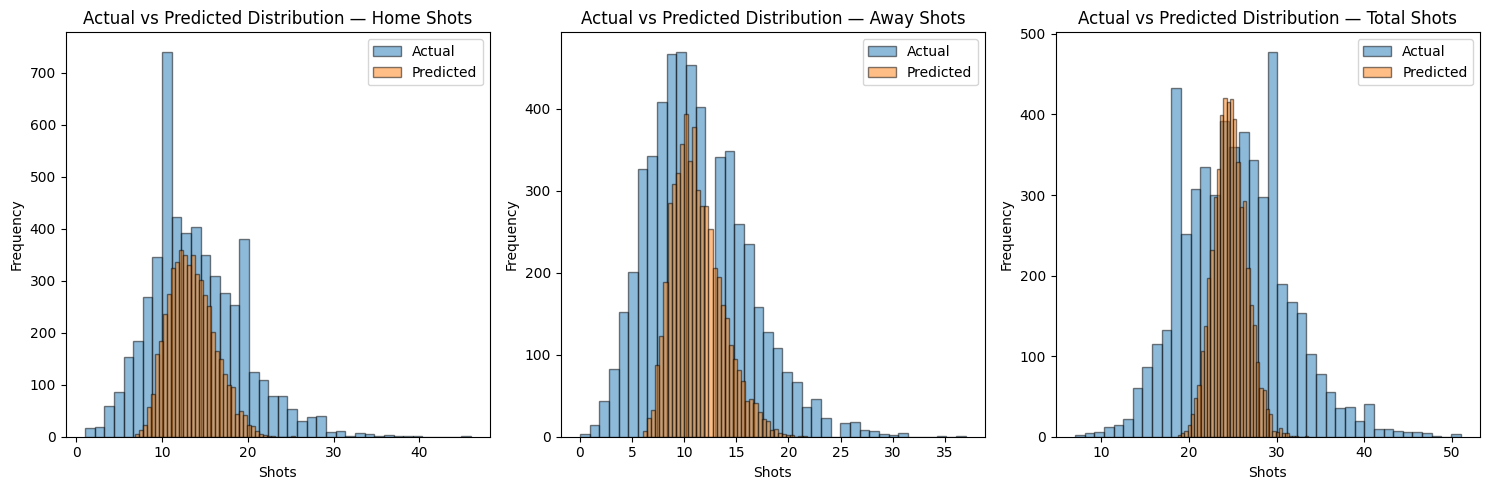

In [9]:
TARGETS = [
    ('pred_home',  'actual_home',  'Home Shots'),
    ('pred_away',  'actual_away',  'Away Shots'),
    ('pred_total', 'actual_total', 'Total Shots'),
]

def plot_diagnostics(results_df, plot_type, league_col=None):
    """
    Generate a 1×3 diagnostic plot for home, away, and total shots.

    plot_type options:
        'scatter'     — actual vs predicted scatter
        'residuals'   — residuals vs predicted
        'hist'        — residual distribution histogram
        'time'        — residuals over time with rolling mean
        'by_league'   — residual boxplot by league
        'distribution'— overlaid actual vs predicted histograms
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, (pred_col, actual_col, title) in zip(axes, TARGETS):
        residuals = results_df[actual_col] - results_df[pred_col]

        if plot_type == 'scatter':
            ax.scatter(results_df[actual_col], results_df[pred_col], alpha=0.3, s=10)
            lo = min(results_df[actual_col].min(), results_df[pred_col].min())
            hi = max(results_df[actual_col].max(), results_df[pred_col].max())
            ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5)
            ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
            ax.set_title(f'Actual vs Predicted — {title}')

        elif plot_type == 'residuals':
            ax.scatter(results_df[pred_col], residuals, alpha=0.3, s=10)
            ax.axhline(0, color='r', linestyle='--', linewidth=1.5)
            ax.set_xlabel('Predicted'); ax.set_ylabel('Residual')
            ax.set_title(f'Residuals vs Predicted — {title}')

        elif plot_type == 'hist':
            ax.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
            ax.axvline(0, color='r', linestyle='--', linewidth=1.5)
            ax.annotate(f'Mean: {residuals.mean():.2f}\nStd: {residuals.std():.2f}',
                        xy=(0.05, 0.95), xycoords='axes fraction', va='top', fontsize=9)
            ax.set_xlabel('Residual'); ax.set_ylabel('Frequency')
            ax.set_title(f'Residual Distribution — {title}')

        elif plot_type == 'time':
            ax.scatter(results_df['date'], residuals, alpha=0.2, s=5)
            ax.axhline(0, color='r', linestyle='--', linewidth=1.5)
            ax.plot(results_df['date'], residuals.rolling(50).mean(),
                    color='orange', linewidth=1.5, label='Rolling mean')
            ax.set_xlabel('Date'); ax.set_ylabel('Residual')
            ax.set_title(f'Residuals over Time — {title}')
            ax.legend(); ax.tick_params(axis='x', rotation=45)

        elif plot_type == 'by_league':
            assert league_col is not None, "Pass league_col for 'by_league' plot"
            plot_df = pd.DataFrame({'residual': residuals, 'league': league_col.values})
            leagues = plot_df['league'].unique()
            ax.boxplot([plot_df[plot_df['league'] == l]['residual'] for l in leagues],
                       labels=leagues)
            ax.axhline(0, color='r', linestyle='--', linewidth=1.5)
            ax.set_xlabel('League'); ax.set_ylabel('Residual')
            ax.set_title(f'Residuals by League — {title}')
            ax.tick_params(axis='x', rotation=45)

        elif plot_type == 'distribution':
            ax.hist(results_df[actual_col], bins=40, alpha=0.5, label='Actual', edgecolor='black')
            ax.hist(results_df[pred_col],   bins=40, alpha=0.5, label='Predicted', edgecolor='black')
            ax.set_xlabel('Shots'); ax.set_ylabel('Frequency')
            ax.set_title(f'Actual vs Predicted Distribution — {title}')
            ax.legend()

    plt.tight_layout()
    plt.show()

league_series = data_2.iloc[MIN_TRAIN_SIZE:].reset_index(drop=True)['league']

plot_diagnostics(results_df, 'scatter')
plot_diagnostics(results_df, 'residuals')
plot_diagnostics(results_df, 'hist')
plot_diagnostics(results_df, 'time')
plot_diagnostics(results_df, 'by_league', league_col=league_series)
plot_diagnostics(results_df, 'distribution')

### F tests to check if the model is any good and check against League

Test to check model against a baseline intercept benchmark

In [10]:
def fit_ols_pair(X_h, X_a, Y_h, Y_a):
    """Fit an OLS model for home and away using statsmodels. Returns (home_model, away_model)."""
    home = sm.OLS(Y_h, sm.add_constant(X_h)).fit()
    away = sm.OLS(Y_a, sm.add_constant(X_a)).fit()
    return home, away


def partial_f_test(full_model, reduced_model, n_restrictions):
    """Compute partial F-statistic and p-value comparing full vs reduced OLS model."""
    F_stat  = ((reduced_model.ssr - full_model.ssr) / n_restrictions) / (full_model.ssr / full_model.df_resid)
    p_value = 1 - stats.f.cdf(F_stat, n_restrictions, full_model.df_resid)
    return F_stat, p_value


def print_f_test(variable_label, F_home, p_home, F_away, p_away):
    """Print partial F-test results for home and away models."""
    for side, F, p in [('HOME', F_home, p_home), ('AWAY', F_away, p_away)]:
        print(f"{side} MODEL — Partial F-test for {variable_label}")
        print(f"F-statistic: {F:.4f}")
        print(f"P-value:     {p:.6f}\n")


def compare_models(label_a, model_h_a, model_a_a, label_b, model_h_b, model_a_b):
    """Print a side-by-side comparison table of two model variants (home and away)."""
    metrics = [
        ('R²',         'rsquared'),
        ('Adj R²',     'rsquared_adj'),
        ('AIC',        'aic'),
        ('BIC',        'bic'),
        ('F-statistic','fvalue'),
    ]
    for side, m_a, m_b in [('HOME', model_h_a, model_h_b), ('AWAY', model_a_a, model_a_b)]:
        print(f"\n{side} MODEL COMPARISON")
        print(f"{'Metric':<20} {label_a:>16} {label_b:>16}")
        print('-' * 54)
        for name, attr in metrics:
            print(f"{name:<20} {getattr(m_a, attr):>16.4f} {getattr(m_b, attr):>16.4f}")

In [11]:
X_h_train = X_home.iloc[:MIN_TRAIN_SIZE]
X_a_train = X_away.iloc[:MIN_TRAIN_SIZE]
Y_h_train = Y_home.iloc[:MIN_TRAIN_SIZE]
Y_a_train = Y_away.iloc[:MIN_TRAIN_SIZE]

home_model_sm, away_model_sm = fit_ols_pair(X_h_train, X_a_train, Y_h_train, Y_a_train)

print("HOME MODEL")
print(home_model_sm.summary())
print("\nAWAY MODEL")
print(away_model_sm.summary())

HOME MODEL
                            OLS Regression Results                            
Dep. Variable:             home_shots   R-squared:                       0.278
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     109.6
Date:                Mon, 30 Mar 2026   Prob (F-statistic):          4.82e-136
Time:                        18:49:06   Log-Likelihood:                -5742.4
No. Observations:                2000   AIC:                         1.150e+04
Df Residuals:                    1992   BIC:                         1.155e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const              

Test to check if it makes sense to keep league

In [12]:
league_cols = [c for c in X_home.columns if 'league' in c]

X_h_no_league = X_h_train.drop(columns=league_cols)
X_a_no_league = X_a_train.drop(columns=league_cols)

home_model_no_league, away_model_no_league = fit_ols_pair(
    X_h_no_league, X_a_no_league, Y_h_train, Y_a_train
)

n_league_dummies = len(league_cols)
F_home, p_home = partial_f_test(home_model_sm, home_model_no_league, n_league_dummies)
F_away, p_away = partial_f_test(away_model_sm, away_model_no_league, n_league_dummies)

print_f_test('league', F_home, p_home, F_away, p_away)
compare_models('With League', home_model_sm, away_model_sm,
               'No League',   home_model_no_league, away_model_no_league)

HOME MODEL — Partial F-test for league
F-statistic: 3.0135
P-value:     0.028996

AWAY MODEL — Partial F-test for league
F-statistic: 1.7031
P-value:     0.164329


HOME MODEL COMPARISON
Metric                    With League        No League
------------------------------------------------------
R²                             0.2780           0.2747
Adj R²                         0.2755           0.2733
AIC                        11500.8240       11503.8803
BIC                        11545.6312       11531.8848
F-statistic                  109.5798         188.9325

AWAY MODEL COMPARISON
Metric                    With League        No League
------------------------------------------------------
R²                             0.2654           0.2635
Adj R²                         0.2628           0.2620
AIC                        11268.1960       11267.3194
BIC                        11313.0033       11295.3239
F-statistic                  102.7957         178.4265


The model is better without league variable.

Test to check if we should keep draw probability

In [13]:
X_h_no_probd = X_h_no_league.drop(columns=['prob_d'])
X_a_no_probd = X_a_no_league.drop(columns=['prob_d'])

home_model_no_probd, away_model_no_probd = fit_ols_pair(
    X_h_no_probd, X_a_no_probd, Y_h_train, Y_a_train
)

F_home, p_home = partial_f_test(home_model_no_league, home_model_no_probd, 1)
F_away, p_away = partial_f_test(away_model_no_league, away_model_no_probd, 1)

print_f_test('prob_d', F_home, p_home, F_away, p_away)
compare_models('No League', home_model_no_league, away_model_no_league,
               'No League/prob_d', home_model_no_probd, away_model_no_probd)

HOME MODEL — Partial F-test for prob_d
F-statistic: 0.6362
P-value:     0.425186

AWAY MODEL — Partial F-test for prob_d
F-statistic: 11.1454
P-value:     0.000858


HOME MODEL COMPARISON
Metric                      No League No League/prob_d
------------------------------------------------------
R²                             0.2747           0.2745
Adj R²                         0.2733           0.2734
AIC                        11503.8803       11502.5180
BIC                        11531.8848       11524.9216
F-statistic                  188.9325         251.7438

AWAY MODEL COMPARISON
Metric                      No League No League/prob_d
------------------------------------------------------
R²                             0.2635           0.2594
Adj R²                         0.2620           0.2583
AIC                        11267.3194       11276.4617
BIC                        11295.3239       11298.8653
F-statistic                  178.4265         233.0026


Based on this we choose to remove prob_d as well.

Test to add opposing team probability to win

In [14]:
X_h_with_proba = X_h_no_probd.copy()
X_h_with_proba['prob_a'] = X_away.iloc[:MIN_TRAIN_SIZE]['prob_a'].values

X_a_with_probh = X_a_no_probd.copy()
X_a_with_probh['prob_h'] = X_home.iloc[:MIN_TRAIN_SIZE]['prob_h'].values

home_model_with_proba, away_model_with_probh = fit_ols_pair(
    X_h_with_proba, X_a_with_probh, Y_h_train, Y_a_train
)

F_home, p_home = partial_f_test(home_model_with_proba, home_model_no_probd, 1)
F_away, p_away = partial_f_test(away_model_with_probh, away_model_no_probd, 1)

print_f_test('opposing prob', F_home, p_home, F_away, p_away)
compare_models('Without opp prob', home_model_no_probd,    away_model_no_probd,
               'With opp prob',    home_model_with_proba,  away_model_with_probh)

HOME MODEL — Partial F-test for opposing prob
F-statistic: 0.6362
P-value:     0.425186

AWAY MODEL — Partial F-test for opposing prob
F-statistic: 11.1454
P-value:     0.000858


HOME MODEL COMPARISON
Metric               Without opp prob    With opp prob
------------------------------------------------------
R²                             0.2745           0.2747
Adj R²                         0.2734           0.2733
AIC                        11502.5180       11503.8803
BIC                        11524.9216       11531.8848
F-statistic                  251.7438         188.9325

AWAY MODEL COMPARISON
Metric               Without opp prob    With opp prob
------------------------------------------------------
R²                             0.2594           0.2635
Adj R²                         0.2583           0.2620
AIC                        11276.4617       11267.3194
BIC                        11298.8653       11295.3239
F-statistic                  233.0026         178.4265


We do not add opposing team probability either.

## Poisson model

We use the data we found to predict using a poisson model.

Our current X contains: X_home and X_away

X_home: prob_h, home_adj_shots, away_adj_shots_conc

X_away: prob_a, away_adj_shots, home_adj_shots_conc

These are all which we will use to model distributions, we can always update and test

In [16]:
# additional libraries

In [17]:
y_home = data_2['home_shots']
y_away = data_2['away_shots']

X_home = data_2[['prob_h',  'home_adj_shots', 'away_adj_shots_conc']]
X_away = data_2[['prob_a', 'away_adj_shots', 'home_adj_shots_conc']]

In [19]:
mean = y_home.mean()
var  = y_home.var()
print(f"Mean: {mean:.2f}, Variance: {var:.2f}, Ratio: {var/mean:.2f}")

Mean: 13.48, Variance: 28.76, Ratio: 2.13


In [20]:
mean = y_away.mean()
var  = y_away.var()
print(f"Mean: {mean:.2f}, Variance: {var:.2f}, Ratio: {var/mean:.2f}")

Mean: 11.13, Variance: 23.01, Ratio: 2.07


In [21]:
print(f"Zero counts: {(y_home == 0).mean():.2%}")
print(f"Zero counts: {(y_away == 0).mean():.2%}")

Zero counts: 0.00%
Zero counts: 0.07%
